## 1. Geração da base específica para a rede neural GRU

Nesta etapa, a base geral tratada é carregada a partir do arquivo `trafego_tratado.csv`. A partir dela, será construída uma base específica para a rede neural GRU.

Diferentemente do SVR, que utiliza uma base tabular, a GRU trabalha com sequências temporais. Por isso, os dados serão posteriormente reorganizados em janelas de observações anteriores, permitindo que o modelo utilize o comportamento recente da série para prever o valor futuro de `Visualizações`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# 1. Leitura da base geral tratada
# ============================================================

df = pd.read_csv("../dados/trafego_tratado.csv")

# Converte a coluna de data
df["Data"] = pd.to_datetime(df["Data"])

# Garante ordenação cronológica
df = df.sort_values("Data").reset_index(drop=True)

print("Base geral tratada carregada com sucesso.")
print(f"Total de registros: {len(df)}")
print(f"Período: {df['Data'].min().date()} a {df['Data'].max().date()}")
print(df.head())
print(df.info())

Base geral tratada carregada com sucesso.
Total de registros: 1020
Período: 2023-07-01 a 2026-04-15
        Data  Sessões  Usuários ativos  Visualizações  dia_semana  \
0 2023-07-01     3109             2047           5566           6   
1 2023-07-02     3099             2083           5498           7   
2 2023-07-03    24119            13516          46786           1   
3 2023-07-04    23635            13335          44984           2   
4 2023-07-05    22217            13014          43559           3   

   fim_de_semana  mes  recesso_judiciario  feriado_nacional_fixo  carnaval  \
0              1    7                   0                      0         0   
1              1    7                   0                      0         0   
2              0    7                   0                      0         0   
3              0    7                   0                      0         0   
4              0    7                   0                      0         0   

   quarta_cinzas

## 2. Seleção das variáveis para a base da GRU

Nesta etapa, são selecionadas as variáveis que serão utilizadas pela rede neural GRU. A variável principal continua sendo `Visualizações`, que será o alvo da previsão. Também são mantidas as variáveis auxiliares de tráfego, como `Sessões` e `Usuários ativos`, além dos atributos temporais e de calendário criados na etapa de tratamento comum.

Como a GRU trabalha com sequências temporais, essas variáveis serão posteriormente normalizadas e reorganizadas em janelas de observações anteriores.

In [2]:
df_gru = df.copy()

colunas_gru = [
    "Data",
    "Visualizações",
    "Sessões",
    "Usuários ativos",
    "dia_semana",
    "fim_de_semana",
    "mes",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

df_gru = df_gru[colunas_gru].copy()

# Salva uma base intermediária específica da GRU
df_gru.to_csv("../dados/trafego_gru_visualizacoes.csv", index=False)

print("Base inicial para GRU criada com sucesso.")
print("Arquivo salvo em: ../dados/trafego_gru_visualizacoes.csv")
print(f"Total de registros: {len(df_gru)}")
print(f"Total de colunas: {df_gru.shape[1]}")
print(df_gru.head())
print(df_gru.info())

Base inicial para GRU criada com sucesso.
Arquivo salvo em: ../dados/trafego_gru_visualizacoes.csv
Total de registros: 1020
Total de colunas: 15
        Data  Visualizações  Sessões  Usuários ativos  dia_semana  \
0 2023-07-01           5566     3109             2047           6   
1 2023-07-02           5498     3099             2083           7   
2 2023-07-03          46786    24119            13516           1   
3 2023-07-04          44984    23635            13335           2   
4 2023-07-05          43559    22217            13014           3   

   fim_de_semana  mes  recesso_judiciario  feriado_nacional_fixo  carnaval  \
0              1    7                   0                      0         0   
1              1    7                   0                      0         0   
2              0    7                   0                      0         0   
3              0    7                   0                      0         0   
4              0    7                   0         

## 3. Separação preliminar e normalização dos dados

Antes da criação das sequências temporais, os dados foram separados em treino e teste de forma cronológica. Os últimos 60 dias foram reservados para teste, enquanto os registros anteriores foram utilizados para treinamento.

Como redes neurais são sensíveis à escala das variáveis, os dados foram normalizados com `MinMaxScaler`. O ajuste do normalizador foi realizado apenas sobre os dados de treino e depois aplicado aos dados de teste, evitando vazamento de informação.

In [3]:
from sklearn.preprocessing import MinMaxScaler

dias_teste = 60
janela = 30

# Colunas usadas como entrada da GRU
# A variável Visualizações também entra como histórico da própria série
colunas_modelo = [
    "Visualizações",
    "Sessões",
    "Usuários ativos",
    "dia_semana",
    "fim_de_semana",
    "mes",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

dados_modelo = df_gru[colunas_modelo].copy()

# Índice da variável-alvo dentro da matriz
idx_alvo = colunas_modelo.index("Visualizações")

# Separação preliminar:
# treino: tudo antes dos últimos 60 dias
# teste: últimos 60 dias + janela anterior para formar as sequências
dados_treino = dados_modelo.iloc[:-dias_teste].copy()
dados_teste = dados_modelo.iloc[-(dias_teste + janela):].copy()

datas_teste_gru = df_gru["Data"].iloc[-dias_teste:].copy()

# Normalização ajustada apenas no treino
scaler = MinMaxScaler()
dados_treino_scaled = scaler.fit_transform(dados_treino)
dados_teste_scaled = scaler.transform(dados_teste)

print("Separação preliminar e normalização realizadas com sucesso.")
print(f"Registros para treino: {len(dados_treino)}")
print(f"Registros para teste + janela: {len(dados_teste)}")
print(f"Período de teste: {datas_teste_gru.min().date()} a {datas_teste_gru.max().date()}")
print(f"Total de variáveis usadas no modelo: {len(colunas_modelo)}")

Separação preliminar e normalização realizadas com sucesso.
Registros para treino: 960
Registros para teste + janela: 90
Período de teste: 2026-02-15 a 2026-04-15
Total de variáveis usadas no modelo: 14


## 4. Criação das sequências temporais

Nesta etapa, os dados normalizados são reorganizados em sequências temporais. Cada amostra de entrada contém uma janela de 30 dias anteriores, e o alvo corresponde ao valor de `Visualizações` do dia seguinte.

Essa estrutura permite que a GRU aprenda padrões sequenciais da série, utilizando o comportamento recente do tráfego e dos atributos auxiliares para prever a quantidade de visualizações.

In [4]:
def criar_sequencias(dados, janela, idx_alvo):
    """
    Cria sequências temporais para modelos recorrentes.
    
    X: janela de observações anteriores
    y: valor da variável-alvo no dia seguinte à janela
    """
    X, y = [], []

    for i in range(janela, len(dados)):
        X.append(dados[i-janela:i, :])
        y.append(dados[i, idx_alvo])

    return np.array(X), np.array(y)


# Sequências de treino
X_train_gru, y_train_gru = criar_sequencias(
    dados_treino_scaled,
    janela,
    idx_alvo
)

# Sequências de teste
X_test_gru, y_test_gru = criar_sequencias(
    dados_teste_scaled,
    janela,
    idx_alvo
)

print("Sequências temporais criadas com sucesso.")
print(f"Formato de X_train_gru: {X_train_gru.shape}")
print(f"Formato de y_train_gru: {y_train_gru.shape}")
print(f"Formato de X_test_gru : {X_test_gru.shape}")
print(f"Formato de y_test_gru : {y_test_gru.shape}")

Sequências temporais criadas com sucesso.
Formato de X_train_gru: (930, 30, 14)
Formato de y_train_gru: (930,)
Formato de X_test_gru : (60, 30, 14)
Formato de y_test_gru : (60,)


## 5. Construção da rede neural GRU

Nesta etapa, é construída a arquitetura da rede neural recorrente GRU. O modelo recebe como entrada sequências de 30 dias, cada uma contendo as variáveis de tráfego e os atributos temporais e de calendário.

Foi utilizada uma camada GRU seguida de camadas densas para gerar a previsão da variável `Visualizações` no dia seguinte. Como se trata de um problema de regressão, a camada de saída possui apenas um neurônio.

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reprodutibilidade básica
np.random.seed(42)
tf.random.set_seed(42)

# Dimensões de entrada
n_timesteps = X_train_gru.shape[1]   # 30 dias
n_features = X_train_gru.shape[2]    # 14 variáveis

modelo_gru = Sequential([
    GRU(
        units=32,
        activation="tanh",
        input_shape=(n_timesteps, n_features)
    ),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

modelo_gru.compile(
    optimizer="adam",
    loss="mse"
)

modelo_gru.summary()

c:\Users\DIOGO\Desktop\Vs Code Git Hub\mp-Diogo\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Treinamento da rede neural GRU

Nesta etapa, a rede GRU é treinada com as sequências temporais geradas a partir do conjunto de treino. Foi utilizado o recurso de parada antecipada, ou `EarlyStopping`, para interromper o treinamento caso o erro de validação deixe de melhorar, reduzindo o risco de sobreajuste.

Uma parte dos dados de treino foi reservada automaticamente para validação durante o treinamento.

In [6]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

historico_gru = modelo_gru.fit(
    X_train_gru,
    y_train_gru,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("Treinamento concluído.")

Epoch 1/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0820 - val_loss: 0.0423
Epoch 2/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0440 - val_loss: 0.0280
Epoch 3/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0315 - val_loss: 0.0276
Epoch 4/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0281 - val_loss: 0.0173
Epoch 5/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0228 - val_loss: 0.0160
Epoch 6/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0187 - val_loss: 0.0126
Epoch 7/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0173 - val_loss: 0.0117
Epoch 8/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0157 - val_loss: 0.0117
Epoch 9/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0167 - val_loss: 0.0109
Epoch 10/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0154 - val_loss: 0.0098
Epoch 11/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0142 - val_loss: 0.0100
Epoch 12/200
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0

## 7. Avaliação da GRU no conjunto de teste

Após o treinamento, a GRU foi aplicada ao conjunto de teste. Como os dados foram normalizados antes do treinamento, as previsões e os valores reais foram reconvertidos para a escala original de visualizações antes do cálculo das métricas.

O desempenho foi avaliado por RMSE, MAE, MAPE e R², permitindo comparação posterior com os demais algoritmos testados.

In [7]:
def calcular_mape(y_true, y_pred):
    """Calcula o MAPE em porcentagem."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mascara = y_true != 0
    return np.mean(np.abs((y_true[mascara] - y_pred[mascara]) / y_true[mascara])) * 100


def inverter_escala_alvo(valores_normalizados, scaler, idx_alvo, n_features):
    """
    Reconverte a variável-alvo para a escala original.
    Como o scaler foi ajustado com várias variáveis, é necessário criar
    uma matriz auxiliar com o mesmo número de colunas.
    """
    matriz_auxiliar = np.zeros((len(valores_normalizados), n_features))
    matriz_auxiliar[:, idx_alvo] = valores_normalizados.reshape(-1)

    valores_originais = scaler.inverse_transform(matriz_auxiliar)[:, idx_alvo]
    return valores_originais


# Previsão normalizada
y_pred_gru_scaled = modelo_gru.predict(X_test_gru)

# Reconverte y real e y previsto para a escala original
y_test_gru_original = inverter_escala_alvo(
    y_test_gru,
    scaler,
    idx_alvo,
    len(colunas_modelo)
)

y_pred_gru_original = inverter_escala_alvo(
    y_pred_gru_scaled,
    scaler,
    idx_alvo,
    len(colunas_modelo)
)

# Cálculo das métricas
rmse_gru = np.sqrt(mean_squared_error(y_test_gru_original, y_pred_gru_original))
mae_gru = mean_absolute_error(y_test_gru_original, y_pred_gru_original)
mape_gru = calcular_mape(y_test_gru_original, y_pred_gru_original)
r2_gru = r2_score(y_test_gru_original, y_pred_gru_original)

print("=" * 60)
print("AVALIAÇÃO GRU - ÚLTIMOS 60 DIAS")
print("=" * 60)
print(f"RMSE: {rmse_gru:.2f}")
print(f"MAE : {mae_gru:.2f}")
print(f"MAPE: {mape_gru:.2f}%")
print(f"R²  : {r2_gru:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
AVALIAÇÃO GRU - ÚLTIMOS 60 DIAS
RMSE: 6053.25
MAE : 3181.51
MAPE: 30.00%
R²  : 0.8627


## 8. Visualização dos valores reais e previstos pela GRU

Após a avaliação quantitativa, foi gerado um gráfico comparando os valores reais e previstos pela GRU no conjunto de teste. Essa visualização permite verificar se o modelo acompanha os picos e quedas da série e em quais períodos apresenta maior erro.

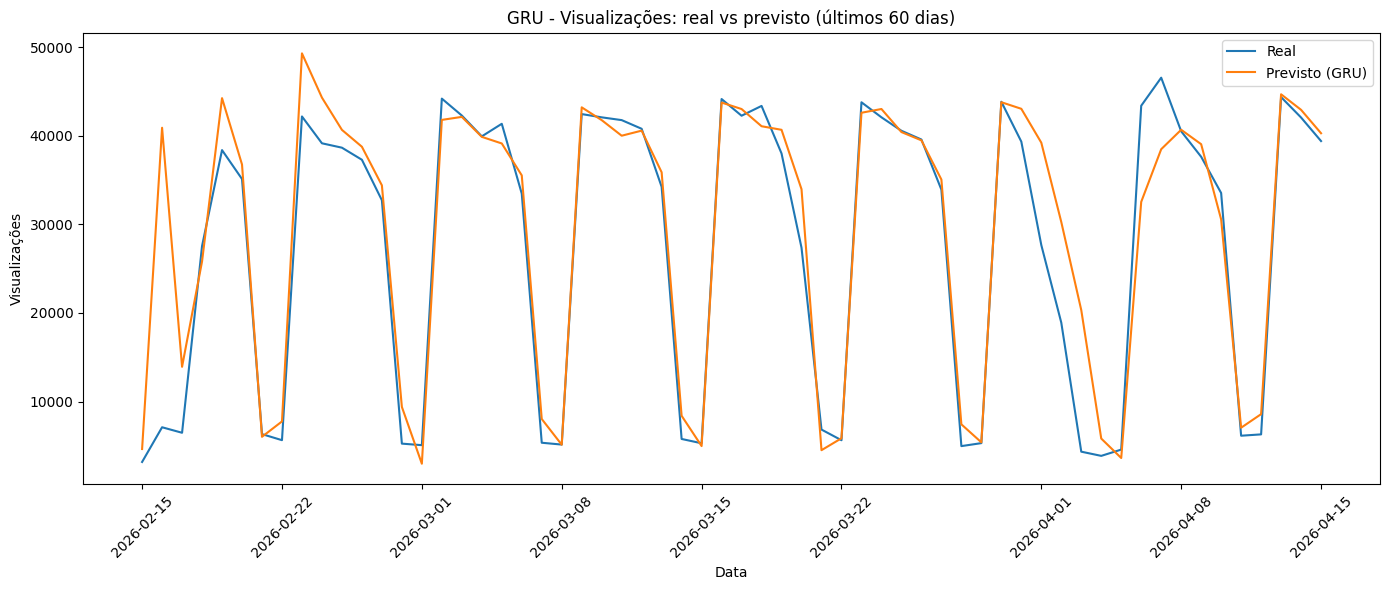

In [8]:
plt.figure(figsize=(14, 6))
plt.plot(datas_teste_gru, y_test_gru_original, label="Real")
plt.plot(datas_teste_gru, y_pred_gru_original, label="Previsto (GRU)")

plt.title("GRU - Visualizações: real vs previsto (últimos 60 dias)")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 9. Salvamento das métricas e previsões da GRU

Ao final da execução, foram salvas as métricas de desempenho da GRU e as previsões realizadas para o conjunto de teste. Esses arquivos serão utilizados posteriormente na etapa de comparação entre os algoritmos avaliados.

In [9]:
metricas_gru = pd.DataFrame({
    "modelo": ["GRU"],
    "rmse": [rmse_gru],
    "mae": [mae_gru],
    "mape": [mape_gru],
    "r2": [r2_gru]
})

metricas_gru.to_csv("../dados/metricas_gru.csv", index=False)

previsao_gru = pd.DataFrame({
    "Data": datas_teste_gru.values,
    "real": y_test_gru_original,
    "previsto_gru": y_pred_gru_original
})

previsao_gru["erro"] = previsao_gru["real"] - previsao_gru["previsto_gru"]
previsao_gru["erro_absoluto"] = abs(previsao_gru["erro"])
previsao_gru["erro_percentual_abs"] = (
    previsao_gru["erro_absoluto"] / previsao_gru["real"]
) * 100

previsao_gru.to_csv("../dados/previsao_gru_visualizacoes.csv", index=False)

print("Arquivos salvos com sucesso:")
print("../dados/metricas_gru.csv")
print("../dados/previsao_gru_visualizacoes.csv")

print("\nMétricas da GRU:")
print(metricas_gru)

print("\nPrimeiras previsões:")
print(previsao_gru.head())

Arquivos salvos com sucesso:
../dados/metricas_gru.csv
../dados/previsao_gru_visualizacoes.csv

Métricas da GRU:
  modelo         rmse          mae       mape        r2
0    GRU  6053.251312  3181.510598  30.000428  0.862696

Primeiras previsões:
        Data     real  previsto_gru          erro  erro_absoluto  \
0 2026-02-15   3182.0   4643.094859  -1461.094859    1461.094859   
1 2026-02-16   7101.0  40908.007833 -33807.007833   33807.007833   
2 2026-02-17   6479.0  13925.637918  -7446.637918    7446.637918   
3 2026-02-18  27554.0  25820.556148   1733.443852    1733.443852   
4 2026-02-19  38385.0  44250.654641  -5865.654641    5865.654641   

   erro_percentual_abs  
0            45.917500  
1           476.087985  
2           114.934989  
3             6.291079  
4            15.281111  
